# Algoritmo DBSCAN 

Es un algoritmo de clustering basado en la densidad que agrupa puntos de datos cercanos entre sí y separa aquellos que están lejos de los demás como ruido o outliers.

Este algoritmono no requiere que el número de clusteres se especifique previamente, ya que, usa dos parámetros:

- eps = la distancia máxima entre dos puntos para que estén en el mismo cluster.
- min_samples = el número mínimo de puntos necesarios para formar un cluster denso.

Este algoritmo es útil cuando los clusteres no necesariamente deban tener formas esféricas y sirve para detectar más eficientemente los outliers (una observación o punto que se aleja de manera significativa del resto de los datos en una muestra) en los datos reales.

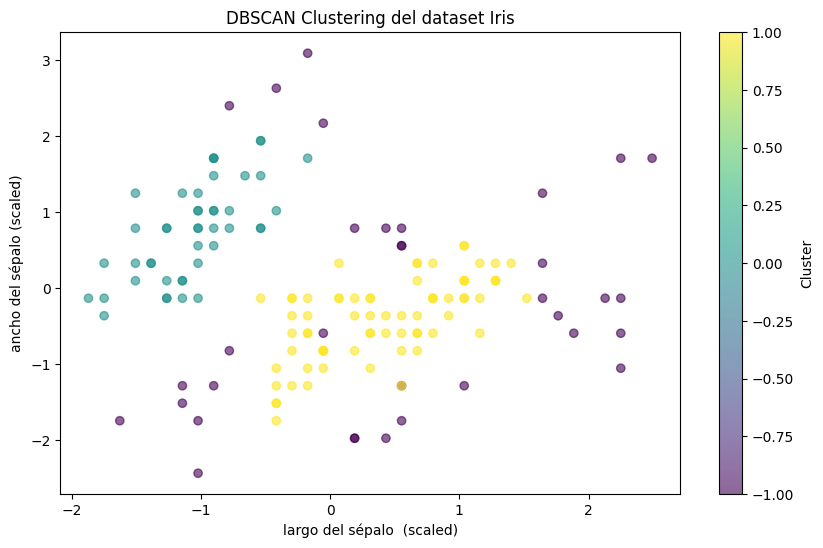

In [1]:
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.cluster import DBSCAN #librería para el algoritmo de clustering DBSCAN
from sklearn.preprocessing import StandardScaler

#Cargar datos
iris = sns.load_dataset('iris')

#Seleccionar características numéricas
x = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

#Estandarizar los datos
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#Aplicar DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5) #Los parámetros eps y min_samples pueden ajustarse según el dataset y los datos que se manejan
clusters = dbscan.fit_predict(x_scaled)

#Etiquetar los clusteres
clusters_labels = dbscan.labels_

#Visualizar los resultados
plt.figure(figsize=(10, 6))
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=clusters_labels, cmap='viridis', alpha=0.6)
plt.title('DBSCAN Clustering del dataset Iris')
plt.xlabel('largo del sépalo  (scaled)')
plt.ylabel('ancho del sépalo (scaled)')
plt.colorbar(label='Cluster')
plt.show()


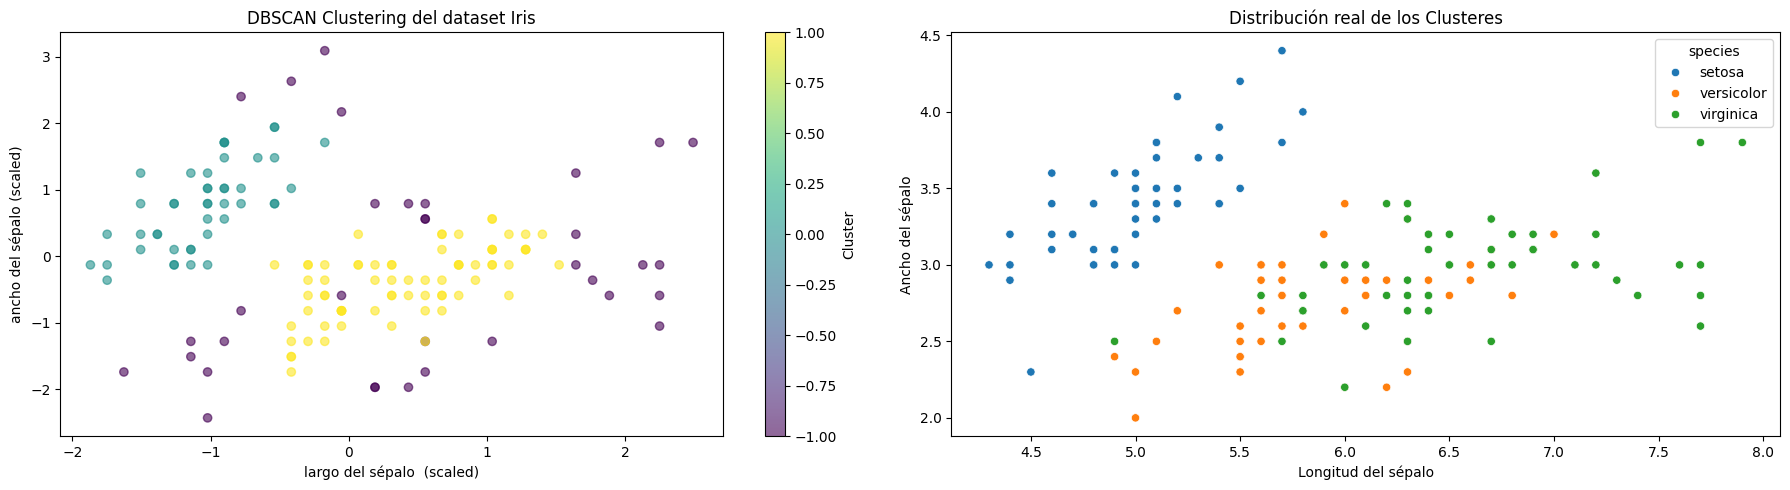

In [2]:
#Usamos Seaborn cuando se tiene una tabla con nombres (iris) y Matplotlib cuando se tiene una matriz de números procesados (x_scaled).

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

#Primer subplot
gráfico_clusteres = axes[0].scatter(x_scaled[:, 0], x_scaled[:, 1], c=clusters_labels, cmap='viridis', alpha=0.6)
axes[0].set_title('DBSCAN Clustering del dataset Iris')
axes[0].set_xlabel('largo del sépalo  (scaled)')
axes[0].set_ylabel('ancho del sépalo (scaled)')
fig.colorbar(gráfico_clusteres, ax=axes[0], label='Cluster')


#Segundo subplot
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", hue="species", ax=axes[1]) #Graficamos las muestras con colores según su especie
axes[1].set_xlabel('Longitud del sépalo') #Etiqueta del eje x
axes[1].set_ylabel('Ancho del sépalo') #Etiqueta del eje y  
axes[1].set_title('Distribución real de los Clusteres') #Título del gráfico


plt.tight_layout()
plt.show()

Salió diferente al k-means, solo identificó dos clusteres, los valores que esten en el color del -1 son considerados outliers, los que estén del color 0 es un cluster, y los que estén del color 1 es el otro cluster.

DBSCAN conecta puntos que están a una distancia eps (épsilon) entre sí. Como las especies Versicolor y Virginica tienen una densidad de puntos continua y solapada, DBSCAN no ve una "brecha" de baja densidad entre ellas, por lo que las trata como una única estructura densa.

El hecho de que haya tanto ruido y que las clases densas se mezclen sugiere que el radio de búsqueda es insuficiente para capturar la estructura global, pero lo suficientemente grande para conectar las dos clases solapadas. 
Mientras K-Medoids siempre dará el número de clústeres que le pidas ($K=3$), DBSCAN intenta descubrirlos. Aquí, DBSCAN falló en descubrir la tercera especie, identificando solo 2 clústeres principales y mucho ruido.

En conclusión, Iris no tiene una estructura de densidad clara con separaciones marcadas. DBSCAN brilla en datasets con formas irregulares basadas en densidad de sus puntos (como lunas o anillos), pero en distribuciones aproximadamente gaussianas o solapadas como esta, funciona muy mal.

# Algoritmo K-MEDOIDS PAM (Partitioning Around Medoids)

Es un algoritmo de clustering basado en la partición de datos similar a k-means pero en ves de utilizar el promedio de los puntos de un cluster como su centroide, k-medoids utiliza puntos reales del conjunto de datos, llamado medoids. El algoritmo comienza con una selección aleatoria de medoids, luego asigna cada punto de datos al medoid más cercano, y posteriormente, actualiza los medoids mediante un proceso iterativo para minimizar la disimilitud dentro de los clusteres.

Este algoritmo es más robusto frente a los outliers, ya que el medoid es menos sensible a los valores extremos que un centroide. K-Medoids es útil en situaciones en las que los datos contienen valores atípicos o cuando los clusteres no tienen formas esféricas.  

In [ ]:
%pip install scikit-learn-extra #Librería abandonada para el uso de Kmedoids

     ---------------------------------------- 0.0/819.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/819.0 kB ? eta -:--:--
     ----------------------------------- - 786.4/819.0 kB 10.9 MB/s eta 0:00:01
     ---------------------------------------- 819.0/819.0 kB 8.2 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build scikit-learn-extra
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for scikit-learn-extra (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [77 lines of output]
      C:\Users\Personal\AppData\Local\Temp\pip-build-env-z305f8cl\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
      !!
      
              ********************************************************************************
              Usage of dash-separated 'description-file' will not be supported in future
              versions. Please use the underscore name 'description_file' instead.
              (Affected: scikit-learn-extra).
      
              Available configuration options are listed in:
              https://setuptools.pypa.io/en/latest/userguide/declarative_config.html
      
              This deprecation is overdue, please update your p

In [ ]:
%pip install kmedoids #Librería alternativa para el uso de Kmedoids, ya que scikit-learn-extra ha sido relativamente abandonada.

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


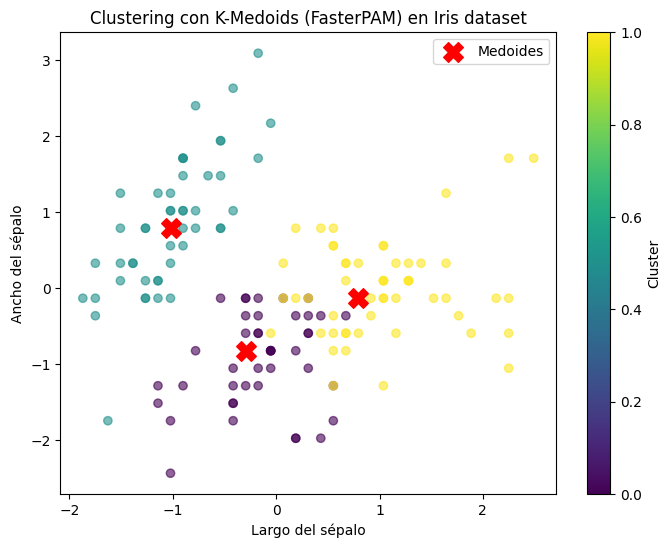

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances #Importación para calcular la matriz de distancias, que es la nueva forma de trabajar con K-Medoids en esta librería.
import kmedoids

# K-Medoids en esta librería requiere calcular la matriz de distancias ANTES. Usamos distancias euclidianas, que es el estándar para datos escalados numéricos.
dist_matrix = pairwise_distances(x_scaled, metric='euclidean')

# Aplicar K-Medoids
# random_state no siempre se usa de la misma forma en métodos exactos como PAM, pero lo dejamos para consistencia si la librería lo soporta en tu versión.
# Usamos 'fasterpam' que es el método más rápido que el estándar.
kmed = kmedoids.KMedoids(n_clusters=3, method='fasterpam', random_state=42) 

# Aquí pasamos 'dist_matrix', NO 'x_scaled'
kmed.fit(dist_matrix) 

# Agregar etiquetas de clúster
# La sintaxis para obtener labels es la misma
clusters_labels = kmed.labels_


# Visualización 
plt.figure(figsize=(8,6))

# Dibujar los puntos (usando largo y ancho del sépalo)
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=clusters_labels, cmap="viridis", alpha=0.6)

# En K-Medoids, los centros son puntos reales del dataset (medoides). La librería nos da los ÍNDICES de esos puntos.

medoid_indices = kmed.medoid_indices_
medoids = x_scaled[medoid_indices] # Obtenemos las coordenadas reales de los medoides

# Ahora dibujamos los medoides (usando solo las 2 primeras columnas para el gráfico)
plt.scatter(medoids[:, 0], medoids[:, 1], c="red", marker="X", s=200, label="Medoides") 
plt.xlabel("Largo del sépalo")
plt.ylabel("Ancho del sépalo")
plt.title("Clustering con K-Medoids (FasterPAM) en Iris dataset")
plt.colorbar(label="Cluster")
plt.legend() # Leyenda para el label "Medoides"
plt.show()



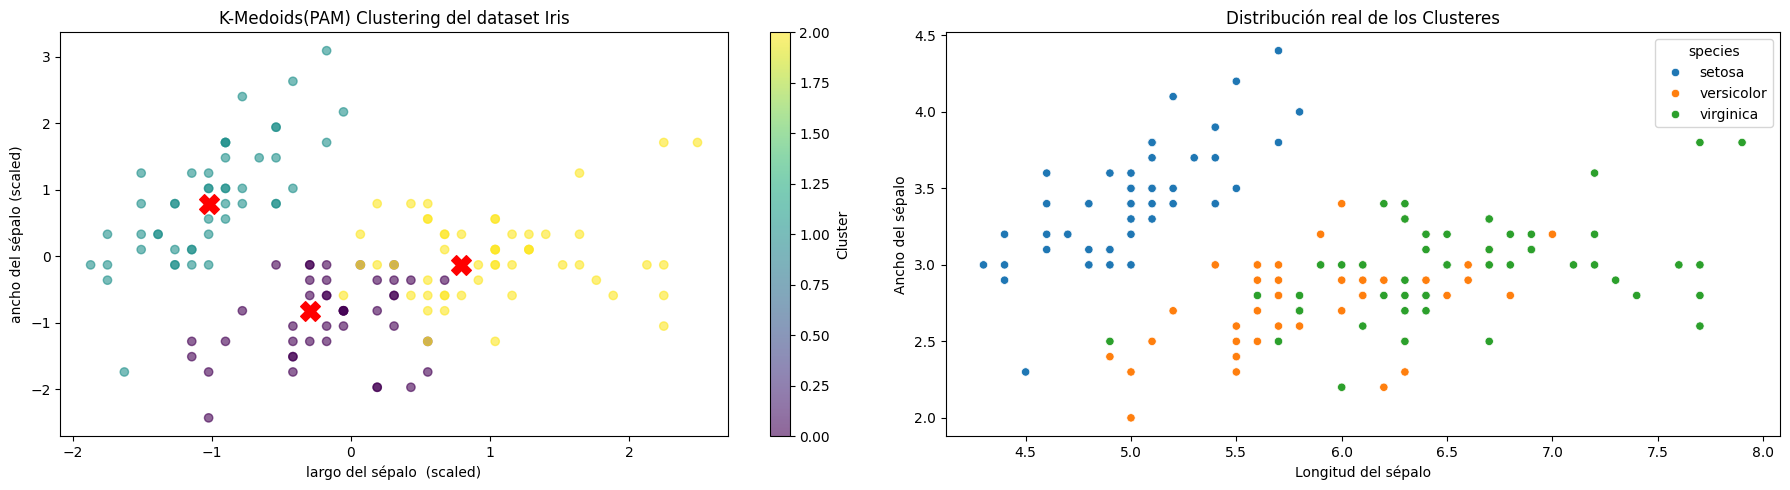

In [4]:
#Usamos Seaborn cuando se tiene una tabla con nombres (iris) y Matplotlib cuando se tiene una matriz de números procesados (x_scaled).
#Figura comparativa con el dataset real 

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

#Primer subplot

gráfico_clusteres = axes[0].scatter(x_scaled[:, 0], x_scaled[:, 1], c=clusters_labels, cmap='viridis', alpha=0.6)
marca_medoides = axes[0].scatter(medoids[:, 0], medoids[:, 1], c="red", marker="X", s=200, label="Medoides") # Agregamos la leyenda para los medoides
axes[0].set_title('K-Medoids(PAM) Clustering del dataset Iris')
axes[0].set_xlabel('largo del sépalo  (scaled)')
axes[0].set_ylabel('ancho del sépalo (scaled)')
fig.colorbar(gráfico_clusteres, ax=axes[0], label='Cluster')


#Segundo subplot
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", hue="species", ax=axes[1]) #Graficamos las muestras con colores según su especie
axes[1].set_xlabel('Longitud del sépalo') #Etiqueta del eje x
axes[1].set_ylabel('Ancho del sépalo') #Etiqueta del eje y  
axes[1].set_title('Distribución real de los Clusteres') #Título del gráfico


plt.tight_layout()
plt.show()

El algoritmo K-Medoids logró una separación prácticamente perfecta del cluster setosa. Esto se debe a que la especie Setosa es linealmente separable de las otras dos. K-Medoids identifica correctamente su medoid central sin ruido.

En los clústeres Versicolor y Virginica estas dos clases se solapan significativamente en sus dimensiones de sépalo. K-Medoids forzó una frontera de decisión geométrica clara, pero la realidad biológica del dataset de Iris muestra que hay puntos de Virginica mezclados en territorio de Versicolor. Esto resulta en errores de clasificación inevitables para algoritmos basados en distancias (centroides/medoides).

A diferencia de K-Means, donde el centro es un promedio matemático, aquí las "X" son muestras reales del dataset. Los medoides están bien posicionados en las zonas de mayor densidad de cada clúster.

El uso de medoides en lugar de centroides hace que este modelo sea mucho más robusto a outliers (valores atípicos), algo vital si se escala esto a datos de producción con ruido.

El escalamiento de los datos es importante, ya que, sin él, la variable "Longitud del sépalo" (con valores más altos) habría dominado el cálculo de la distancia euclidiana, sesgando los clústeres. El escalamiento permitió que el ancho y el largo tuvieran el mismo peso en la decisión del algoritmo.

En conclusión, K-Medoids (PAM) es eficiente para este dataset, pero limitado por la naturaleza de los datos. Ningún algoritmo de clustering basado puramente en distancias (como K-Medoids o K-Means) logrará separar perfectamente Versicolor de Virginica usando solo estas dos dimensiones, ya que no hay una separación física real entre ellas en ese espacio vectorial.

<class 'pandas.DataFrame'>


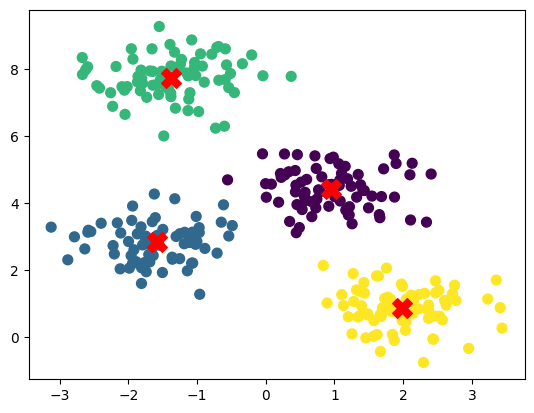

In [5]:
#Evaluar modelos de clustering

from sklearn.metrics import silhouette_score #Importación para evaluar la calidad del clustering usando el coeficiente de silueta.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 


#Generar datos aleatorios de ejemplo
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)   #El guión bajo es para ignorar las etiquetas verdaderas, ya que solo nos interesa el clustering.

#Aplicar K-Means
k_means = KMeans(n_clusters=4)
labels_ejemplo = k_means.fit_predict(X)
print(type(x))

#Graficar los datos con los clusters asignados
plt.scatter(X[:, 0], X[:, 1], c=labels_ejemplo, s=50, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.show()

## Método silhouette 

Es una métrica para medir la calidad del clustering. Proporciona  información sobre la cohesión (qué tan cerca están los puntos dentro de un mismo cluster) y la separación (qué tan lejos están los puntos de diferentes clusteres). Los valores rondan entre -1 y 1 donde:
- 1 significa que los puntos están bien agrupados.
- 0 significa que los puntos están en el borde de dos clusteres.
- -1 significa que los puntos probablemente estén asignados a un cluster que no pertenezcan.



In [6]:
silhouette_score(X, labels_ejemplo) #X son los datos y labels_ejemplo son las etiquetas del cluster

0.6819938690643478

Mientras más cercano este el valor al 1 que al 0 significa que nuestro clustering está bien hecho, si se acerca más al cero significa que se puede mejorar, ya sea estandarizando los datos o aplicando otro algoritmo, y si ya baja de cero practicamente el clustering está mal hecho.

## Inercia

La inercia es la suma de las distancias cuadradas desde cada punto hasta el centro de su cluster correspondiente. Cuanto menor sea la inercia, mejor será el clustering, ya que significa que los puntos están más cerca de los centroides.

La incercia es más utilizada en algoritmos como K-means para determinar cuantos clusters se deben usar, ya que, la inercia disminuye a medida que se agregan más clusters.


In [7]:
k_means.fit(X)
k_means.inertia_

212.00599621083478

Mide qué tan compactos son tus clusters. Mientras más bajo sea el valor, más cerca están los puntos de sus centros.

Si se multiplica todos los datos por 10, la inercia aumentará drásticamente sin que la estructura del cluster haya cambiado. Por eso, siempre se debe normalizar o estandarizar los datos antes de confiar en ella. Por eso, nunca se usa la inercia para decir que un modelo es bueno, sino para comparar diferentes valores de $k$ mediante el Método del Codo.

La inercia falla si los clusters tienen formas alargadas, irregulares o densidades muy distintas. Asume que todos los clusters tienen aproximadamente el mismo tamaño (dispersión).

Este método se lo utiliza en conjunto con el método del codo para definir el número de clusteres:

- Iteración: Ejecutas K-Means en un bucle (ej. para $k$ del 1 al 10).
- Extracción de Inercia: Guardas el atributo .inertia_ de cada ejecución.
- Visualización: Graficas $k$ (eje X) vs. Inercia (eje Y).
- Decisión: Buscas el ángulo más cerrado. Ese codo es el punto de equilibrio entre complejidad del modelo (pocos clusters) y precisión (baja inercia).

# índice de Davies-Bouldin (DBI)

Es una medida que evalúa la separación y compactación de los clusters:
- DBI = 0 Excelente calidad de clustering
- DBI < 1 = Buena calidad de clustering
- 1 <= DBI < 2 = Hay mucho margen de mejora del clustering
- DBI >= 2 = Mala calidad de clustering
Un valor bajo del indice indica un buen clustering, ya que significa que los clusters están bien separados y son compactos.


In [8]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(X, labels_ejemplo)
dbi

0.4375640078237839